# 10 De Novo Mutation Plausibility Calculation

**Methods mapping:** de novo mutation plausibility calculation.

This notebook rebuilds the linked-site facts from the branch-defining analysis, then evaluates simple mutation-rate scenarios for observing all linked sites de novo. The sensitivity grid is generated in this notebook.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('10_de_novo_mutation_plausibility_calculation', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "linked_site_facts": DATA_DIR / "linked_site_fact_table.csv",
    "sensitivity_grid": DATA_DIR / "de_novo_plausibility_sensitivity_grid.csv",
    "figure_png": FIG_DIR / "FigS_de_novo_plausibility.png",
    "figure_pdf": FIG_DIR / "FigS_de_novo_plausibility.pdf",
    "figure_svg": FIG_DIR / "FigS_de_novo_plausibility.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,linked_site_facts,data/processed_data/10_de_novo_mutation_...,False
1,sensitivity_grid,data/processed_data/10_de_novo_mutation_...,True
2,figure_png,results/figures/10_de_novo_mutation...,False
3,figure_pdf,results/figures/10_de_novo_mutation...,False
4,figure_svg,results/figures/10_de_novo_mutation...,False


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/10_de_novo_mutation_plausibility_calculation'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/10_de_novo_mutation_plausibility_calculation'))

## Reconfirm Branch-Defining Site Pattern

Before the probability grid is created, I show the branch combinations and linked sites that will feed into the de novo calculation.


In [3]:
targets = au.select_target_branch_combos(ROOT)
site_sets = au.derive_linked_site_sets(ROOT)
site_table = pd.DataFrame([
    {'project': project, 'position': site['position'], 'ref': site['ref'], 'alt': site['alt']}
    for project, sites in site_sets.items()
    for site in sites
])

display(targets)
display(site_table)


,project,project_label,target_combo,target_branches,n_target_samples,selection_rule
0,PRJNA1037681,Australia,C4+C6,"[C4, C6]",23,most frequent exact cross-branch TreeCluster c...
1,PRJNA1130896,United States,C18+C21,"[C18, C21]",26,most frequent exact cross-branch TreeCluster c...


,project,position,ref,alt
0,PRJNA1037681,5510,G,A
1,PRJNA1037681,5520,A,T
2,PRJNA1037681,5544,C,T
3,PRJNA1037681,5558,G,A
4,PRJNA1037681,5563,T,C
5,PRJNA1130896,5531,T,C
6,PRJNA1130896,5561,T,C


## Generate Mutation-Rate Scenarios

The facts table records the linked-site pattern per cohort. The scenario table expands those facts across mutation rates and serial replication-round assumptions.


In [4]:
facts, scenarios = au.de_novo_plausibility(ROOT, DATA_DIR)

display(facts)
display(scenarios.head(12))


,project,project_label,target_combo,k_linked_sites,observed_target_samples,site_pattern
0,PRJNA1037681,Australia,C4+C6,5,23,5510 G>A; 5520 A>T; 5544 C>T; 5558 G>A; 5563 T>C
1,PRJNA1130896,United States,C18+C21,2,26,5531 T>C; 5561 T>C


,project,project_label,target_combo,k_linked_sites,mu,serial_replication_rounds,p_specific_linked_pattern_upper
0,PRJNA1037681,Australia,C4+C6,5,0.000001,3,2.429982e-28
1,PRJNA1037681,Australia,C4+C6,5,0.000001,5,3.124961e-27
2,PRJNA1037681,Australia,C4+C6,5,0.000001,10,9.999750e-26
3,PRJNA1037681,Australia,C4+C6,5,0.000001,14,5.378052e-25
4,PRJNA1037681,Australia,C4+C6,5,0.000010,3,2.429818e-23
5,PRJNA1037681,Australia,C4+C6,5,0.000010,5,3.124609e-22
6,PRJNA1037681,Australia,C4+C6,5,0.000010,10,9.997500e-21
7,PRJNA1037681,Australia,C4+C6,5,0.000010,14,5.376358e-20
8,PRJNA1037681,Australia,C4+C6,5,0.000100,3,2.428178e-18
9,PRJNA1037681,Australia,C4+C6,5,0.000100,5,3.121096e-17


## Figure

The supplement-style plot is drawn from the regenerated sensitivity grid.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:2047: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


{'png': 'results/figures/10_de_novo_mutation_plausibility_calculation/FigS_de_novo_specific_linked_pattern_upper_bound.png',
 'pdf': 'results/figures/10_de_novo_mutation_plausibility_calculation/FigS_de_novo_specific_linked_pattern_upper_bound.pdf',
 'svg': 'results/figures/10_de_novo_mutation_plausibility_calculation/FigS_de_novo_specific_linked_pattern_upper_bound.svg'}

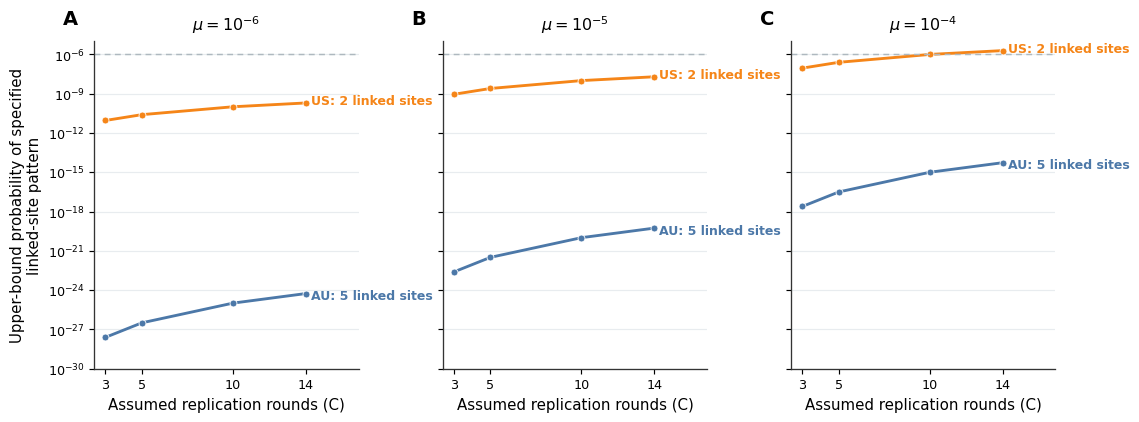

In [5]:
fig, paths = au.draw_de_novo(scenarios, FIG_DIR)
display(paths)
plt.show()
